In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")

warnings.filterwarnings(action="ignore")

#### Sales distribution visualisation

In [2]:
def load_city_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Ensure numeric columns are numeric for aggregation and correlations.
    for col in ["Sheet", "Sales_Sheet", "Sales_pack", "zone_id", "pharmacy_id"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "addeddate" in df.columns:
        df["addeddate_parsed"] = pd.to_datetime(df["addeddate"], errors="coerce")
    else:
        df["addeddate_parsed"] = pd.NaT

    if {"addeddate", "time_"}.issubset(df.columns):
        dt = pd.to_datetime(
            df["addeddate"].astype(str).str.strip() + " " + df["time_"].astype(str).str.strip(),
            errors="coerce",
        )
        df["timestamp"] = dt.fillna(df["addeddate_parsed"])
    else:
        df["timestamp"] = df["addeddate_parsed"]

    return df

In [3]:
def _daily_sales(df: pd.DataFrame, sales_col: str = "Sales_Sheet") -> pd.Series:
    daily = (
        df.dropna(subset=["addeddate_parsed", sales_col])
        .set_index("addeddate_parsed")[sales_col]
        .resample("D")
        .sum()
        .sort_index()
    )
    return daily

In [4]:
def plot_daily_weekly_monthly_sales(df: pd.DataFrame, sales_col: str = "Sales_Sheet"):
    temp = df.dropna(subset=["addeddate_parsed", "zone_id", sales_col]).copy()
    zones = sorted(temp["zone_id"].dropna().unique())

    fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=False)
    titles = ["Daily", "Weekly", "Monthly"]
    freqs = ["D", "W", "ME"]

    for ax, freq, title in zip(axes, freqs, titles):
        for zone in zones:
            zone_data = (
                temp.loc[temp["zone_id"] == zone]
                .set_index("addeddate_parsed")[sales_col]
                .resample(freq)
                .sum()
                .sort_index()
            )
            ax.plot(zone_data.index, zone_data.values, label=f"Zone {int(zone)}", linewidth=1.8)
        ax.set_title(f"{title} Total {sales_col} by Zone")
        ax.set_xlabel("Date")
        ax.set_ylabel("Total Sales")
        ax.legend(title="Zone")

    fig.suptitle(f"Daily / Weekly / Monthly {sales_col} — Zone Comparison", fontsize=13, y=1.01)
    plt.tight_layout()
    return fig, axes

In [5]:
def plot_weekday_hour_heatmap(df: pd.DataFrame, sales_col: str = "Sales_Sheet"):
    temp = df.dropna(subset=["timestamp", sales_col]).copy()
    temp["weekday"] = temp["timestamp"].dt.day_name()
    temp["hour"] = temp["timestamp"].dt.hour

    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    pivot = (
        temp.pivot_table(index="weekday", columns="hour", values=sales_col, aggfunc="sum")
        .reindex(order)
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(pivot, cmap="YlGnBu", ax=ax)
    ax.set_title(f"Weekday x Hour Heatmap ({sales_col})")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Weekday")
    plt.tight_layout()
    return fig, ax

In [6]:
def plot_moving_average_sales(
    df: pd.DataFrame,
    sales_col: str = "Sales_Sheet",
    window_short: int = 7,
    window_long: int = 30,
):
    daily = _daily_sales(df, sales_col=sales_col)
    ma_short = daily.rolling(window_short, min_periods=1).mean()
    ma_long = daily.rolling(window_long, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(daily.index, daily.values, label="Daily", alpha=0.35)
    ax.plot(ma_short.index, ma_short.values, label=f"MA({window_short})", linewidth=2)
    ax.plot(ma_long.index, ma_long.values, label=f"MA({window_long})", linewidth=2)
    ax.set_title(f"Moving Average of Daily {sales_col}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total Sales")
    ax.legend()
    plt.tight_layout()
    return fig, ax

In [7]:
def plot_total_sales_by_zone(df: pd.DataFrame, sales_col: str = "Sales_Sheet"):
    zone_sales = (
        df.groupby("zone_id", dropna=False)[sales_col]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=zone_sales, x="zone_id", y=sales_col, ax=ax, palette="viridis")
    ax.set_title(f"Total {sales_col} by Zone")
    ax.set_xlabel("Zone ID")
    ax.set_ylabel("Total Sales")
    plt.tight_layout()
    return fig, ax

In [8]:
def plot_sales_distribution_by_zone(df: pd.DataFrame, sales_col: str = "Sales_Sheet", kind: str = "violin"):
    temp = df.dropna(subset=["zone_id", sales_col]).copy()

    fig, ax = plt.subplots(figsize=(10, 5))
    if kind.lower() == "box":
        sns.boxplot(data=temp, x="zone_id", y=sales_col, ax=ax)
    else:
        sns.violinplot(data=temp, x="zone_id", y=sales_col, ax=ax, inner="quartile", cut=0)
    ax.set_title(f"Per-Transaction {sales_col} by Zone ({kind.title()})")
    ax.set_xlabel("Zone ID")
    ax.set_ylabel(sales_col)
    plt.tight_layout()
    return fig, ax

In [9]:
def plot_top_n_pharmacies(df: pd.DataFrame, sales_col: str = "Sales_Sheet", top_n: int = 15):
    top = (
        df.groupby("pharmacy_id", dropna=False)[sales_col]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=top, x="pharmacy_id", y=sales_col, ax=ax, palette="mako")
    ax.set_title(f"Top {top_n} Pharmacies by {sales_col}")
    ax.set_xlabel("Pharmacy ID")
    ax.set_ylabel("Total Sales")
    plt.tight_layout()
    return fig, ax

In [10]:
def plot_zone_trend_small_multiples(df: pd.DataFrame, sales_col: str = "Sales_Sheet"):
    temp = df.dropna(subset=["zone_id", "addeddate_parsed", sales_col]).copy()
    zones = sorted(temp["zone_id"].dropna().unique())

    if len(zones) == 0:
        raise ValueError("No valid zone_id values found for plotting.")

    fig, axes = plt.subplots(len(zones), 1, figsize=(13, 3.5 * len(zones)), sharex=True)
    if len(zones) == 1:
        axes = [axes]

    for ax, zone in zip(axes, zones):
        zone_daily = (
            temp.loc[temp["zone_id"] == zone]
            .set_index("addeddate_parsed")[sales_col]
            .resample("D")
            .sum()
            .sort_index()
        )
        ax.plot(zone_daily.index, zone_daily.values, color="tab:blue")
        ax.set_title(f"Zone {int(zone)} Daily {sales_col}")
        ax.set_ylabel("Sales")

    axes[-1].set_xlabel("Date")
    fig.suptitle("Small Multiples: Zone-wise Trends", y=1.01)
    plt.tight_layout()
    return fig, axes

In [11]:
def plot_top_20_products(df: pd.DataFrame, sales_col: str = "Sales_Sheet"):
    top20 = (
        df.groupby("name", dropna=False)[sales_col]
        .sum()
        .sort_values(ascending=False)
        .head(20)
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    top20.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Top 20 Products by Total {sales_col}")
    ax.set_xlabel("Total Sales")
    ax.set_ylabel("Product Name")
    plt.tight_layout()
    return fig, ax

In [12]:
def plot_product_pareto(df: pd.DataFrame, sales_col: str = "Sales_Sheet", top_n: int = 30):
    prod = df.groupby("name", dropna=False)[sales_col].sum().sort_values(ascending=False)
    top = prod.head(top_n)
    cumulative_pct = top.cumsum() / top.sum() * 100

    fig, ax1 = plt.subplots(figsize=(13, 6))
    ax1.bar(top.index.astype(str), top.values, color="steelblue")
    ax1.set_xticklabels(top.index.astype(str), rotation=70, ha="right")
    ax1.set_ylabel("Total Sales")

    ax2 = ax1.twinx()
    ax2.plot(top.index.astype(str), cumulative_pct.values, color="tomato", marker="o")
    ax2.set_ylabel("Cumulative %")
    ax2.set_ylim(0, 105)
    ax2.axhline(80, color="gray", linestyle="--", linewidth=1)

    ax1.set_title(f"Pareto Chart: Top {top_n} Products by {sales_col}")
    plt.tight_layout()
    return fig, (ax1, ax2)

In [13]:
def plot_product_treemap(df: pd.DataFrame, sales_col: str = "Sales_Sheet", top_n: int = 25):
    prod = df.groupby("name", dropna=False)[sales_col].sum().sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(12, 7))
    try:
        import squarify

        labels = [f"{str(k)[:20]}\n{v:,.0f}" for k, v in prod.items()]
        squarify.plot(sizes=prod.values, label=labels, alpha=0.8, ax=ax)
        ax.set_title(f"Treemap: Top {top_n} Products by {sales_col}")
        ax.axis("off")
    except Exception as exc:
        warnings.warn(
            f"Treemap requires 'squarify'. Falling back to horizontal bar chart. Details: {exc}",
            RuntimeWarning,
        )
        prod.sort_values(ascending=True).plot(kind="barh", ax=ax, color="slateblue")
        ax.set_title(f"Treemap fallback (barh): Top {top_n} Products by {sales_col}")
        ax.set_xlabel("Total Sales")
        ax.set_ylabel("Product Name")

    plt.tight_layout()
    return fig, ax

In [14]:
def plot_type_share(df: pd.DataFrame):
    type_counts = df["type"].fillna("Unknown").value_counts()

    fig, ax = plt.subplots(figsize=(7, 7))
    wedges, texts, autotexts = ax.pie(
        type_counts.values,
        labels=type_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"width": 0.45},
    )
    ax.set_title("Type Share (Donut Chart)")
    plt.tight_layout()
    return fig, ax

In [15]:
def plot_type_stacked_area_over_time(df: pd.DataFrame, sales_col: str = "Sales_Sheet"):
    temp = df.dropna(subset=["addeddate_parsed", sales_col]).copy()
    temp["type"] = temp["type"].fillna("Unknown")

    ts = (
        temp.set_index("addeddate_parsed")
        .groupby("type")[sales_col]
        .resample("W")
        .sum()
        .unstack(0)
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(13, 6))
    ts.plot.area(ax=ax, alpha=0.85)
    ax.set_title(f"Stacked Area Over Time by Type ({sales_col}, Weekly)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total Sales")
    plt.tight_layout()
    return fig, ax

In [16]:
def plot_sales_pack_vs_sheet_scatter(df: pd.DataFrame):
    temp = df.dropna(subset=["Sales_pack", "Sales_Sheet"]).copy()

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.regplot(
        data=temp,
        x="Sales_pack",
        y="Sales_Sheet",
        scatter_kws={"alpha": 0.15, "s": 10},
        line_kws={"color": "red"},
        ax=ax,
    )
    ax.set_title("Sales_pack vs Sales_Sheet (with Trendline)")
    plt.tight_layout()
    return fig, ax

In [17]:
def plot_correlation_heatmap(df: pd.DataFrame):
    cols = [c for c in ["Sheet", "Sales_Sheet", "Sales_pack", "zone_id", "pharmacy_id"] if c in df.columns]
    corr = df[cols].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
    ax.set_title("Correlation Heatmap")
    plt.tight_layout()
    return fig, ax

In [18]:
def plot_daily_control_chart(df: pd.DataFrame, sales_col: str = "Sales_Sheet"):
    daily = _daily_sales(df, sales_col=sales_col)
    mean = daily.mean()
    std = daily.std(ddof=0)
    ucl = mean + (3 * std)
    lcl = max(mean - (3 * std), 0)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(daily.index, daily.values, label="Daily Sales", color="tab:blue", alpha=0.8)
    ax.axhline(mean, color="green", linestyle="--", label="Mean")
    ax.axhline(ucl, color="red", linestyle="--", label="UCL (+3 sigma)")
    ax.axhline(lcl, color="orange", linestyle="--", label="LCL (-3 sigma)")
    ax.set_title(f"Control Chart of Daily {sales_col}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total Sales")
    ax.legend()
    plt.tight_layout()
    return fig, ax

In [19]:
def plot_calendar_heatmap(df: pd.DataFrame, sales_col: str = "Sales_Sheet"):
    daily = _daily_sales(df, sales_col=sales_col).to_frame(name="sales").reset_index()
    daily["week"] = daily["addeddate_parsed"].dt.isocalendar().week.astype(int)
    daily["year"] = daily["addeddate_parsed"].dt.isocalendar().year.astype(int)
    daily["weekday"] = daily["addeddate_parsed"].dt.weekday
    daily["year_week"] = daily["year"].astype(str) + "-W" + daily["week"].astype(str).str.zfill(2)

    pivot = daily.pivot_table(index="weekday", columns="year_week", values="sales", aggfunc="sum")
    pivot = pivot.reindex([0, 1, 2, 3, 4, 5, 6])

    fig, ax = plt.subplots(figsize=(max(12, 0.25 * pivot.shape[1]), 4))
    sns.heatmap(pivot, cmap="YlOrRd", ax=ax)
    ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
    ax.set_title("Calendar-like Heatmap of Daily Sales (Weekday x Year-Week)")
    ax.set_xlabel("Year-Week")
    ax.set_ylabel("Weekday")
    plt.tight_layout()
    return fig, ax

In [20]:
def plot_invoice_frequency_distribution(df: pd.DataFrame):
    invoice_counts = df.groupby("Invoice").size()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(invoice_counts, bins=50, kde=True, ax=ax)
    ax.set_title("Invoice-level Transaction Count Distribution")
    ax.set_xlabel("Transactions per Invoice")
    ax.set_ylabel("Number of Invoices")
    plt.tight_layout()
    return fig, ax

In [21]:
def show_all_visualizations(df: pd.DataFrame) -> None:
    """Run every visualization and display inline in the notebook."""
    plot_functions = [
        lambda: plot_daily_weekly_monthly_sales(df),
        lambda: plot_weekday_hour_heatmap(df),
        lambda: plot_moving_average_sales(df),
        lambda: plot_total_sales_by_zone(df),
        lambda: plot_sales_distribution_by_zone(df, kind="violin"),
        lambda: plot_top_n_pharmacies(df),
        lambda: plot_zone_trend_small_multiples(df),
        lambda: plot_top_20_products(df),
        lambda: plot_product_pareto(df),
        lambda: plot_product_treemap(df),
        lambda: plot_type_share(df),
        lambda: plot_type_stacked_area_over_time(df),
        lambda: plot_sales_pack_vs_sheet_scatter(df),
        lambda: plot_correlation_heatmap(df),
        lambda: plot_daily_control_chart(df),
        lambda: plot_calendar_heatmap(df),
        lambda: plot_invoice_frequency_distribution(df),
    ]

    for fn in plot_functions:
        result = fn()
        plt.show()



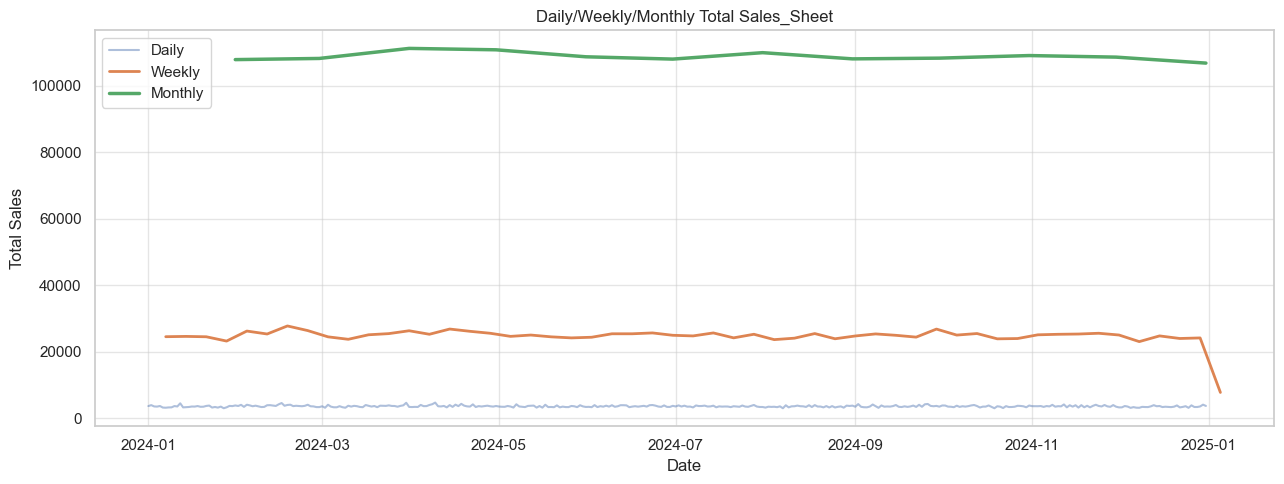

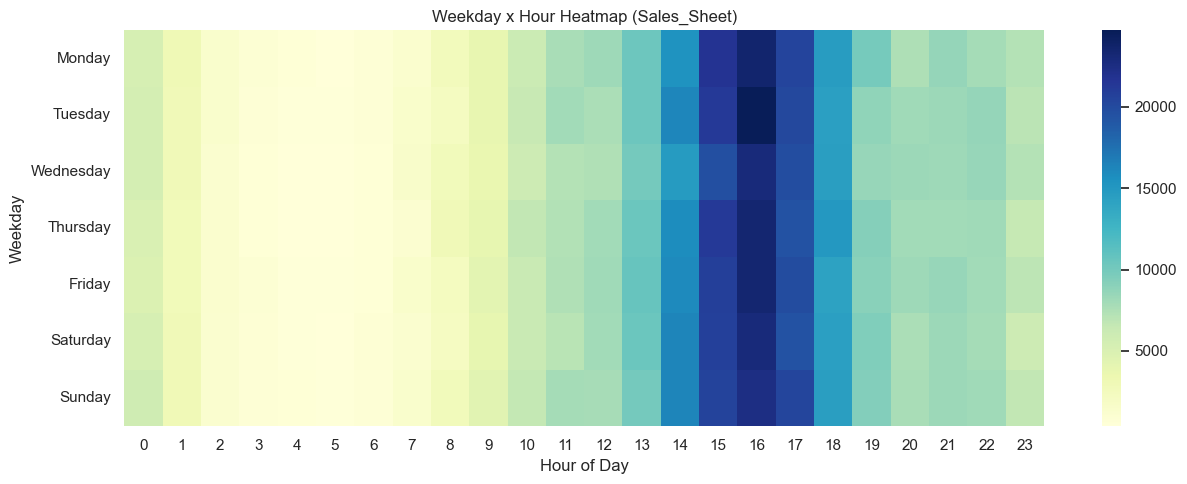

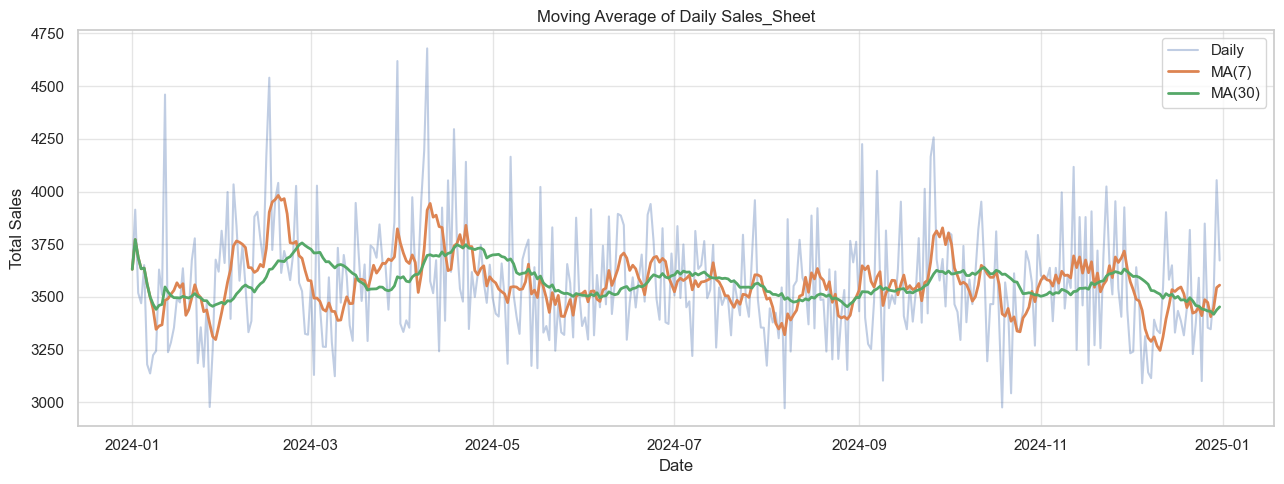

C:\Users\avivekdhait\AppData\Local\Temp\ipykernel_19324\3727728682.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zone_sales, x="zone_id", y=sales_col, ax=ax, palette="viridis")


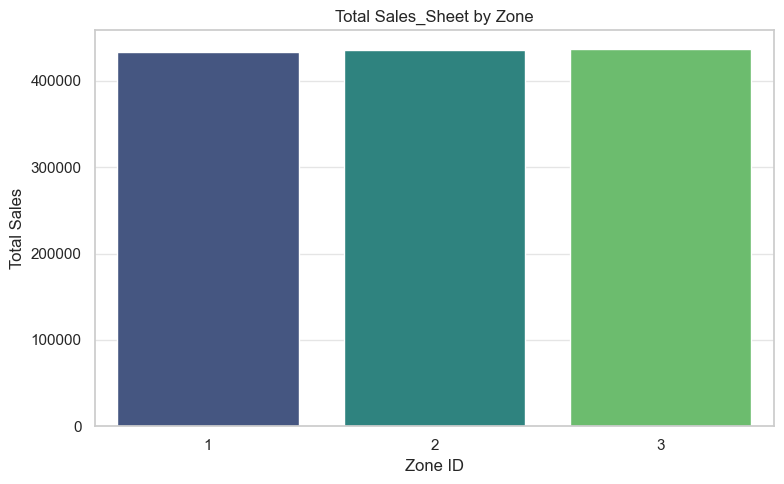

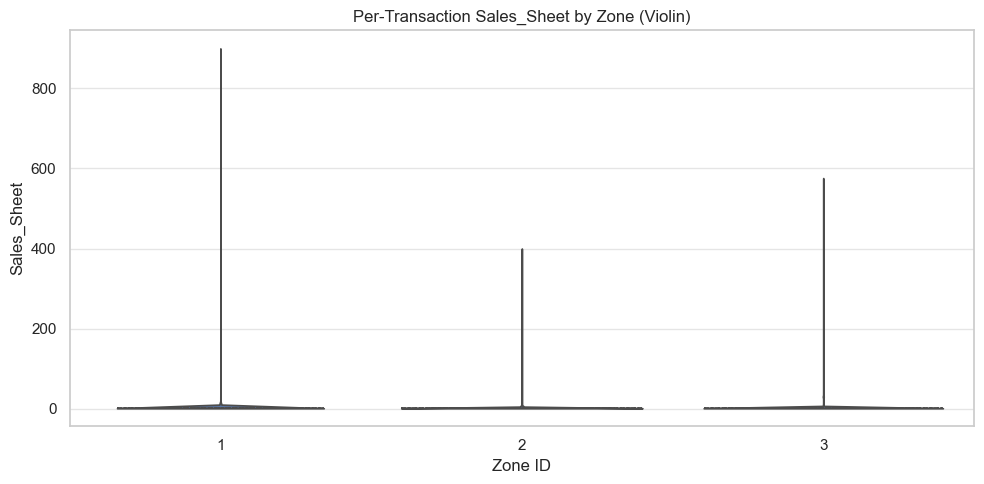

C:\Users\avivekdhait\AppData\Local\Temp\ipykernel_19324\2570407731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x="pharmacy_id", y=sales_col, ax=ax, palette="mako")


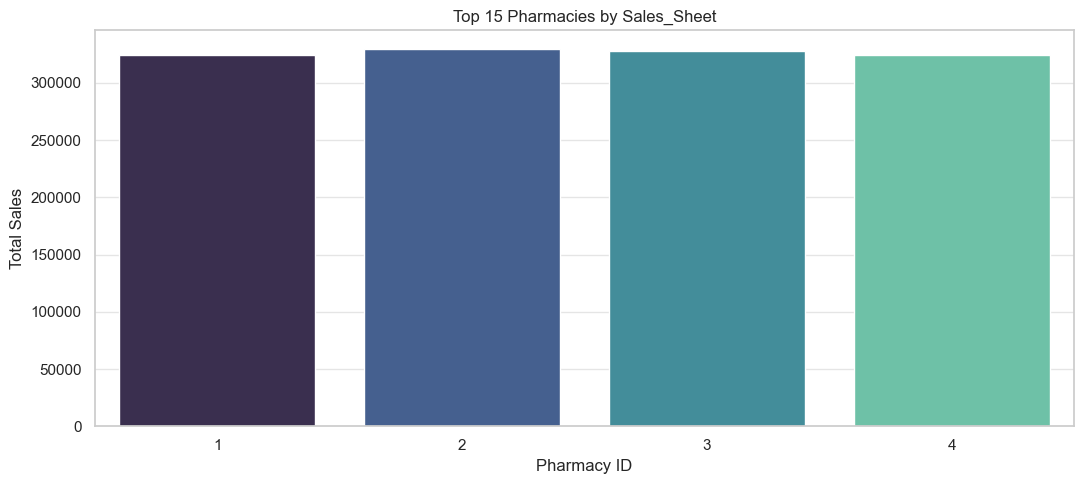

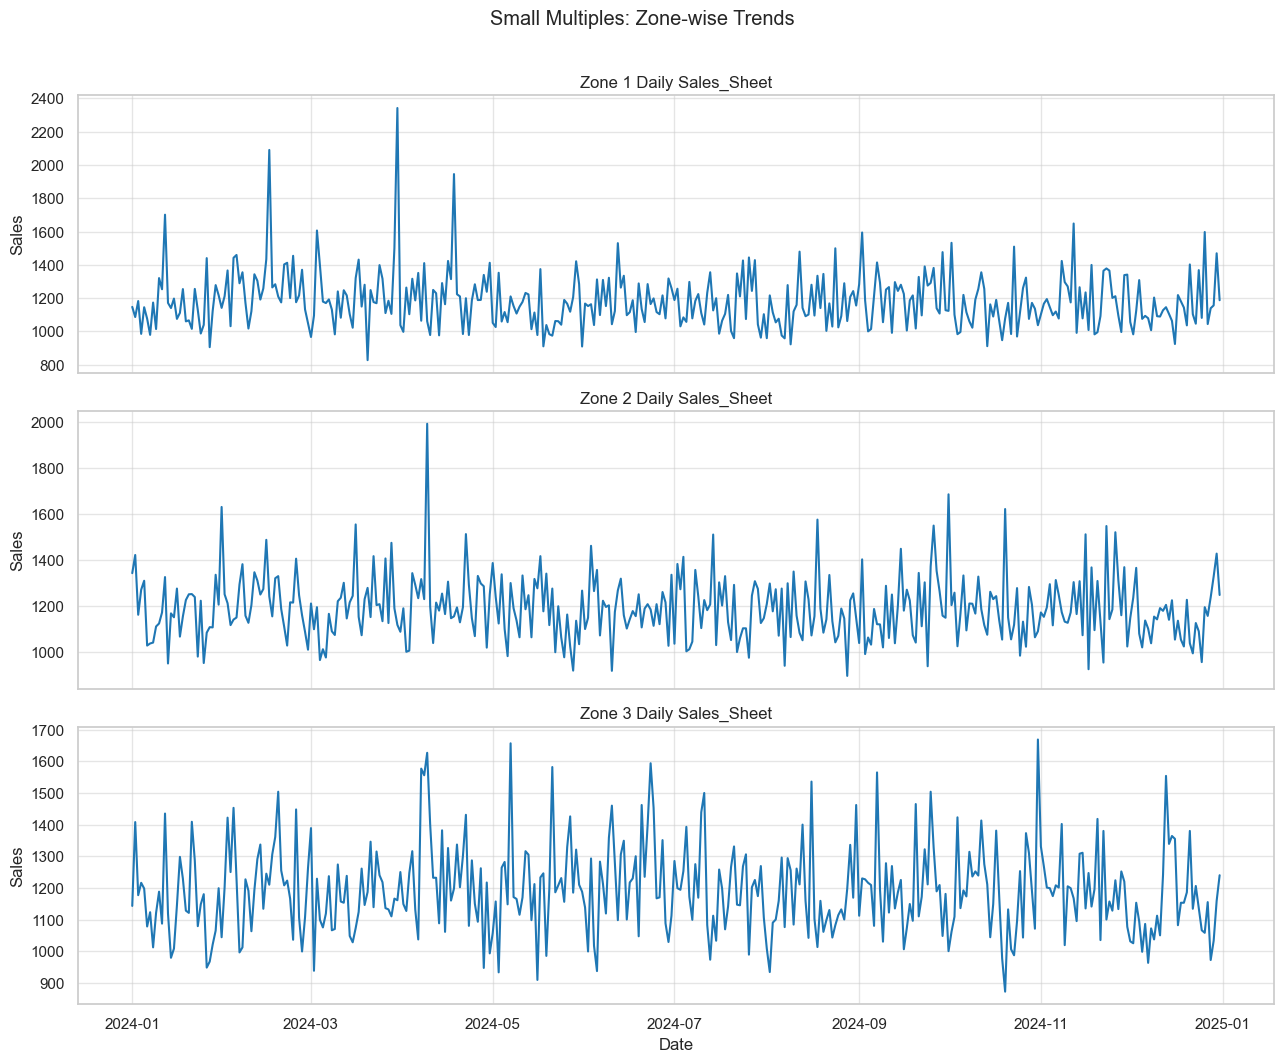

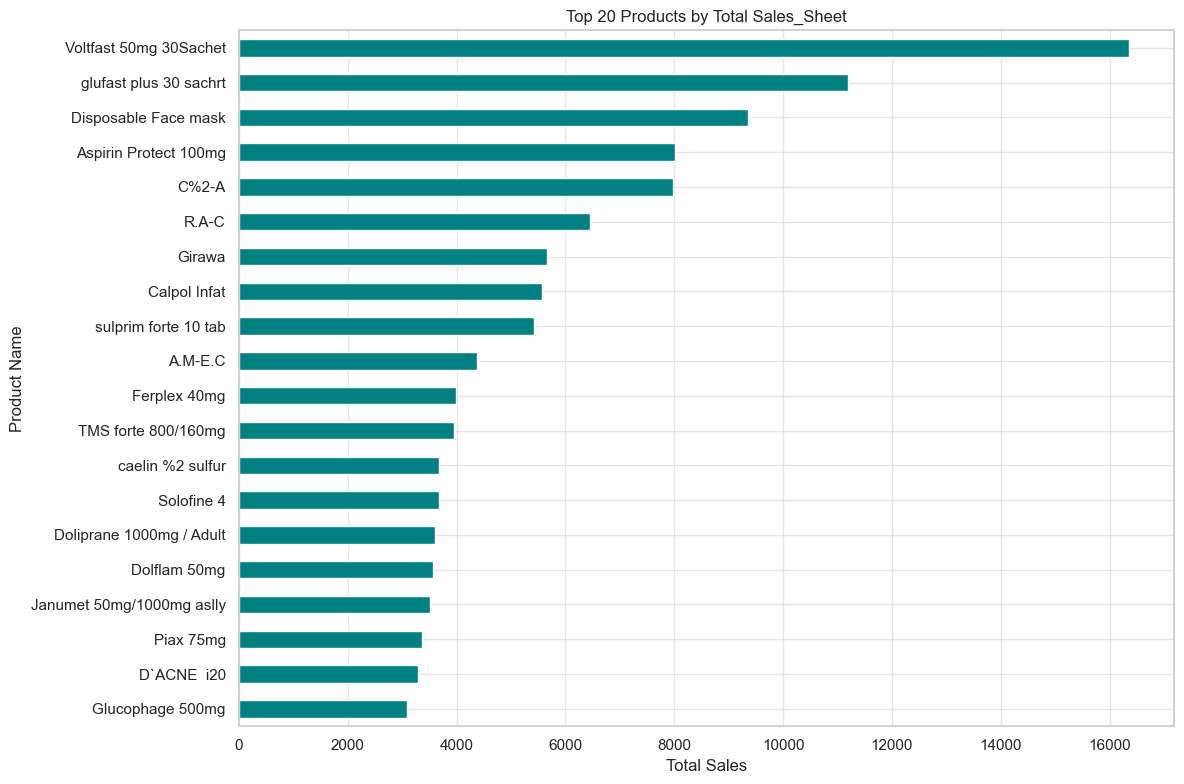

C:\Users\avivekdhait\AppData\Local\Temp\ipykernel_19324\3725932890.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top.index.astype(str), rotation=70, ha="right")


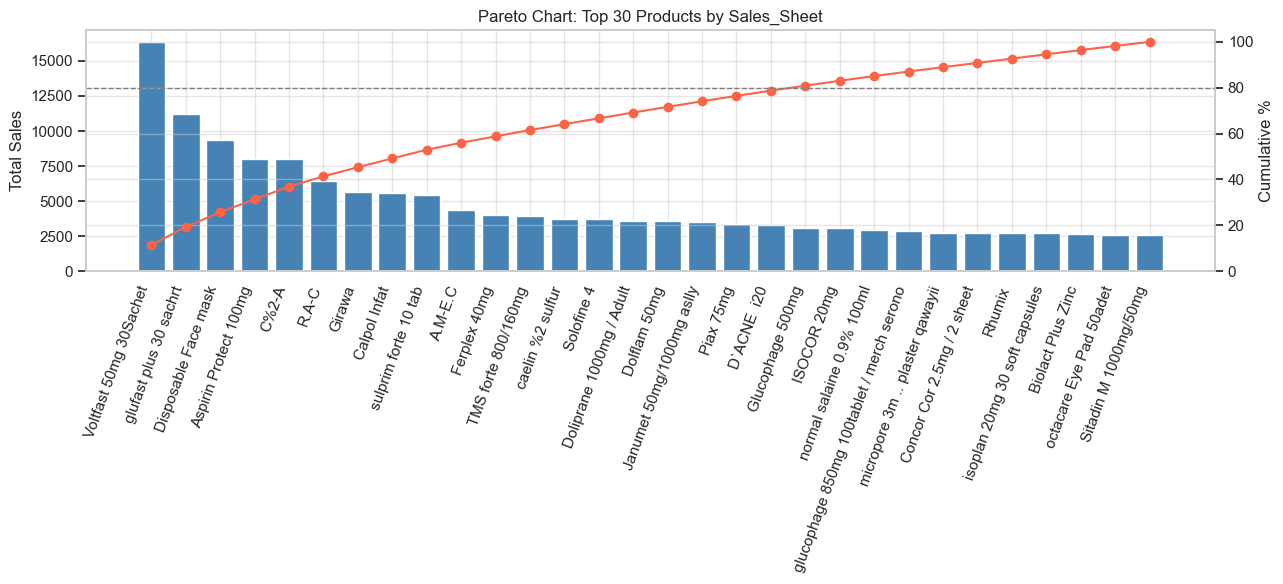

C:\Users\avivekdhait\AppData\Local\Temp\ipykernel_19324\2024052348.py:13: RuntimeWarning: Treemap requires 'squarify'. Falling back to horizontal bar chart. Details: No module named 'squarify'
  warnings.warn(


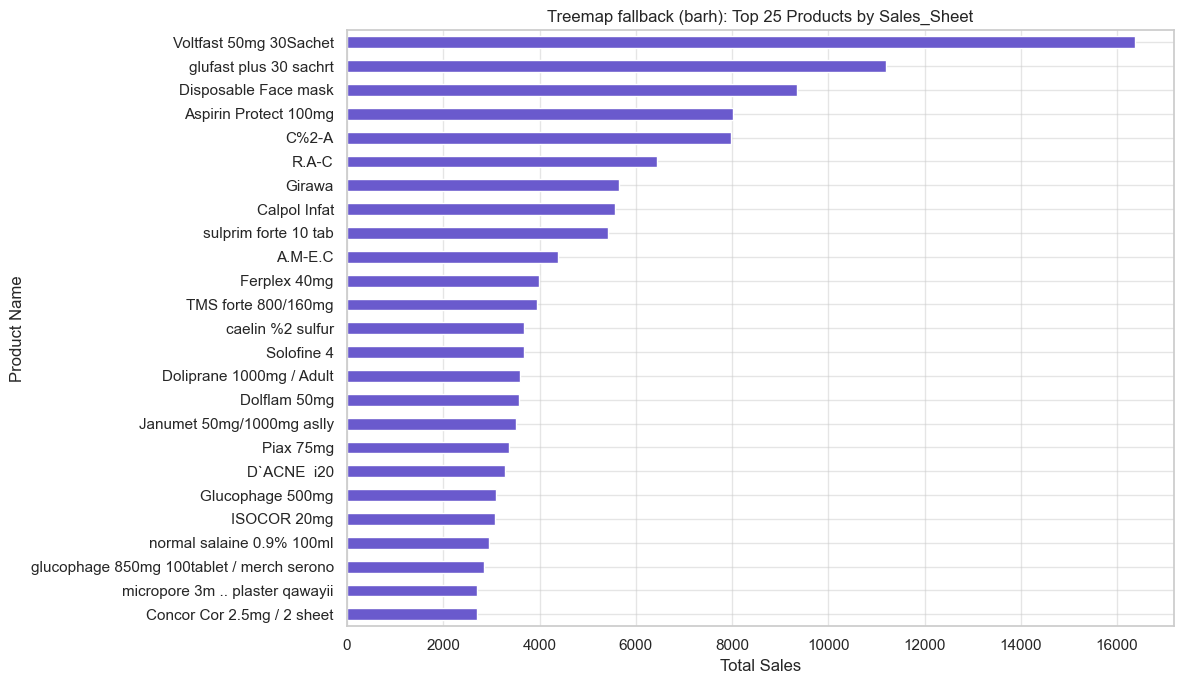

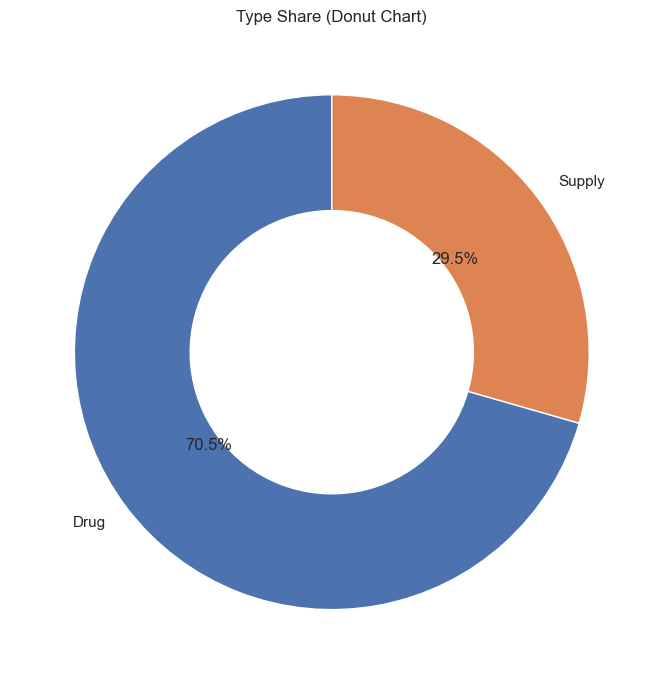

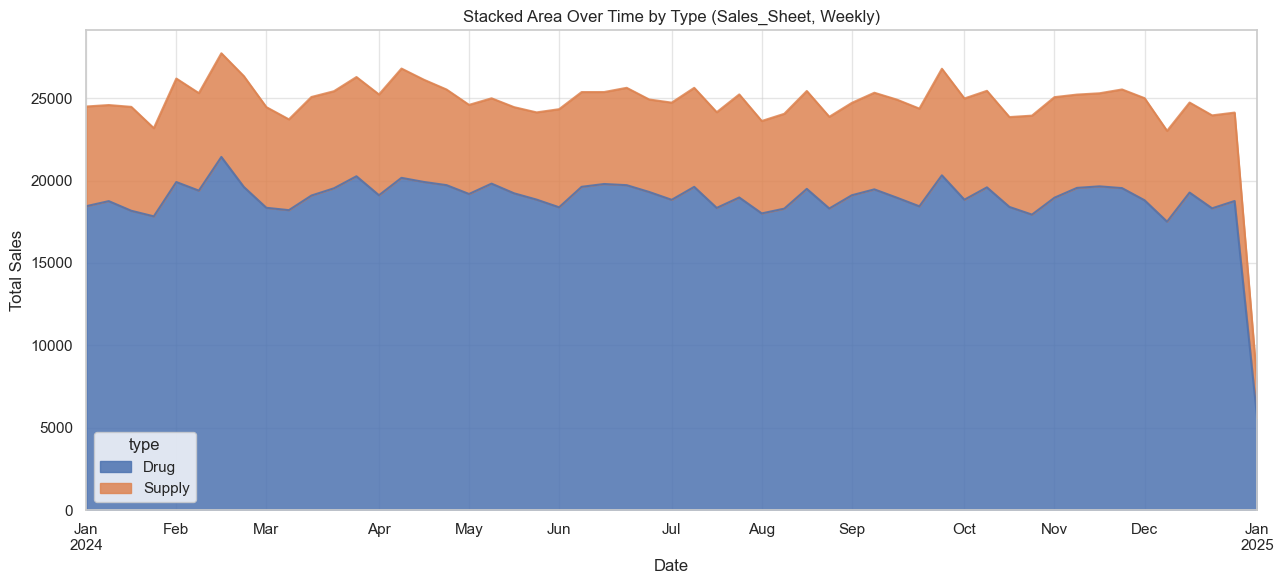

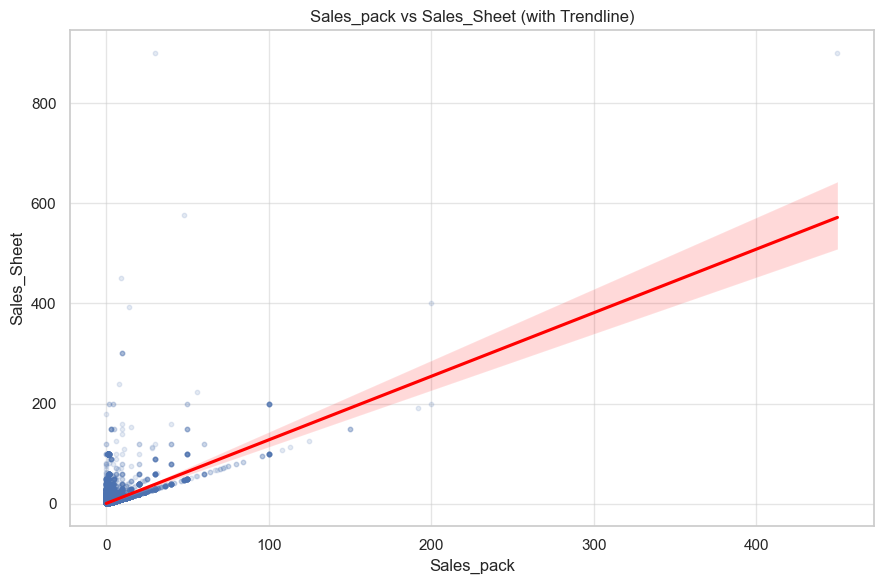

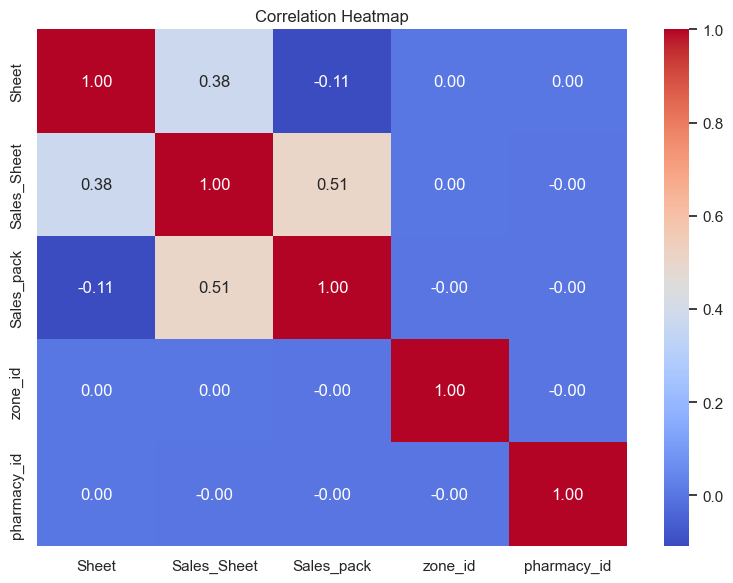

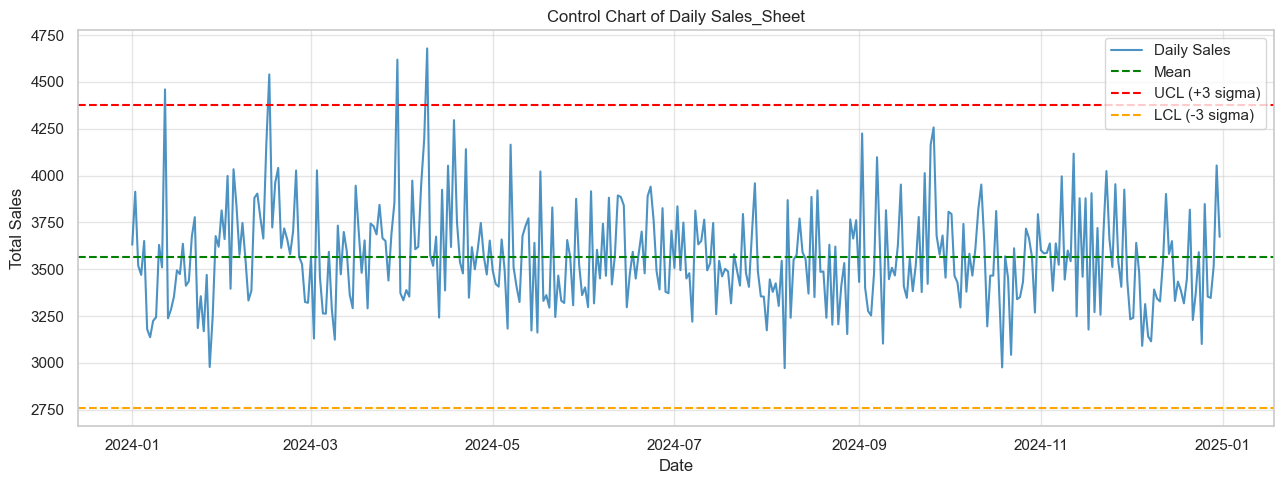

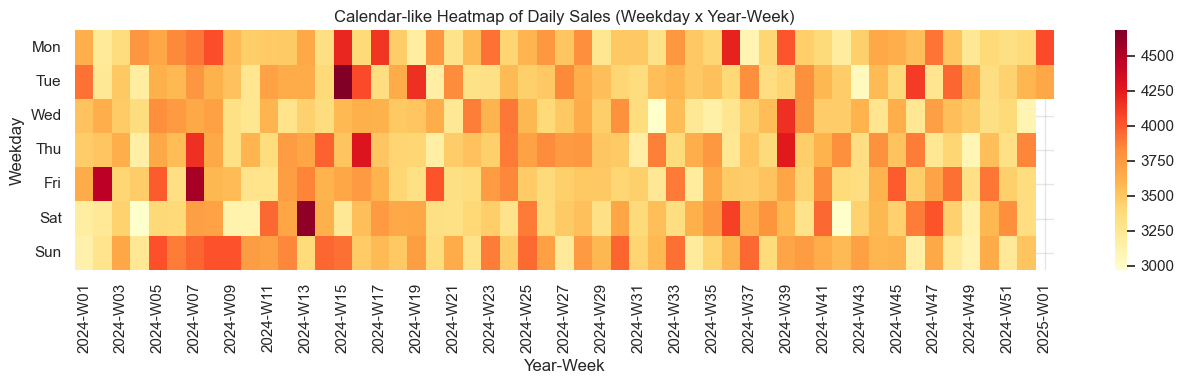

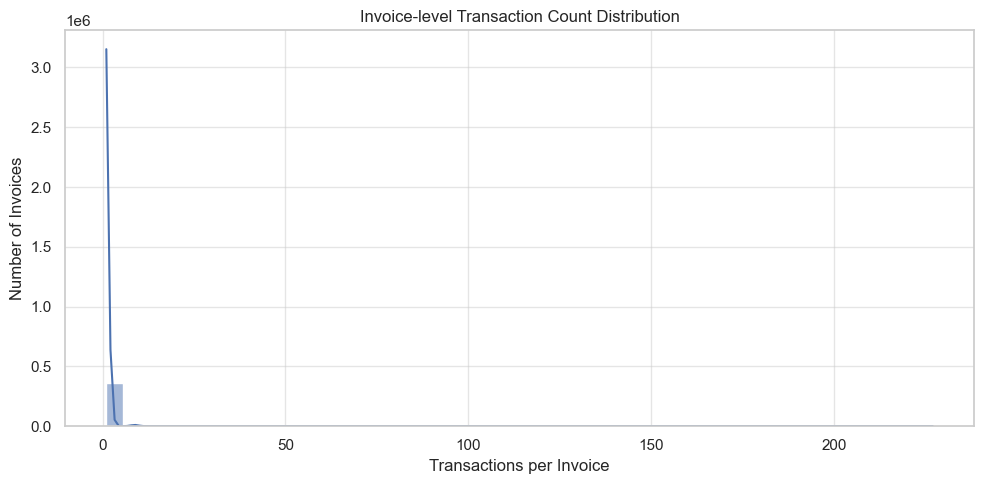

In [22]:
data_path = "../PharmacyTransactionalDataset/City1_allZones.csv"
city_df = load_city_data(data_path)
show_all_visualizations(city_df)
